In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
sys.path.append("..")

from utils import *
import json 
import pandas as pd
import random
from pathlib import Path
import pickle
from transformers import AutoTokenizer
from operator import itemgetter
import matplotlib.pyplot as plt
plt.tight_layout()

/home/pwiesenbach/anaconda3/envs/pytorch/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Figure size 640x480 with 0 Axes>

In [4]:
MODELTYPE = "deepset/gbert-base"
DATASET = "med_indication_all_RF_diag"
DATASETPATH =  Path("../data") / f"ind.{DATASET}"
DATASETFILE = Path("../data") / "medindcls_bert.json"

adj, features, y_train, y_val, y_test, train_mask, val_mask, test_mask, _, _ = load_corpus(DATASETPATH)
doc_mask = train_mask + val_mask + test_mask
adj.sum()

tokenizer = AutoTokenizer.from_pretrained(MODELTYPE)

if not DATASETFILE.exists():
    print("Creating dataset")
    dataset = CleanClinicDataset(tokenizer=tokenizer, clean=False)
    with open(DATASETFILE, "wb") as f:
        print(f"Saving dataset under {DATASETFILE}")
        pickle.dump(dataset, f)
else:
    print(f"Loading dataset from: {DATASETFILE}")
    with open(DATASETFILE, "rb") as f:
        dataset = pickle.load(f)

Loading dataset from: ../data/medindcls_bert.json


/home/pwiesenbach/anaconda3/envs/pytorch/lib/python3.10/site-packages/sklearn/base.py:318: UserWarning: Trying to unpickle estimator LabelEncoder from version 0.22 when using version 1.2.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/pwiesenbach/anaconda3/envs/pytorch/lib/python3.10/site-packages/sklearn/base.py:318: UserWarning: Trying to unpickle estimator OneHotEncoder from version 0.22 when using version 1.2.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tmp/ipykernel_1674908/3214339880.py:21: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` namespace, the `scipy.sparse.csr` namespace is deprecated.
  dataset = pickle.lo

In [5]:
random.seed(0)
idx = np.arange(len(dataset))
random.shuffle(idx)

train_len = 1889
val_len = 270
test_len = 540

train_idx, val_idx, test_idx = (
    idx[: int(len(idx) * 0.7)],
    idx[int(len(idx) * 0.7) : int(len(idx) * 0.8)],
    idx[int(len(idx) * 0.8) :],
)

def map_to_idx(x):
    if x < train_len:
        return train_idx[x]
    elif x < val_len + train_len:
        return val_idx[x - train_len]
    else:
        return test_idx[x - val_len - train_len]

In [6]:
first_order_adj = adj @ adj
first_order_adj = first_order_adj.toarray()

In [7]:
top_n_input = 10
top_input_test_rel_nodes = np.argpartition(first_order_adj[test_mask][:, doc_mask], -top_n_input)[:, -top_n_input:]
top_input_test_rel_nodes = np.vectorize(map_to_idx)(top_input_test_rel_nodes)
top_input_test_rel_nodes

array([[2297, 2296, 2295, ..., 2298, 2294, 2299],
       [  22,   24,   23, ..., 2135, 2133, 2132],
       [2563, 2558, 2561, ..., 2565, 2562, 2564],
       ...,
       [1139, 1133, 1136, ...,  164,  165,  163],
       [1731, 1730, 1733, ..., 1723, 1722, 1735],
       [1548, 1545, 1582, ..., 1577, 1579, 1578]])

In [8]:
input_df = pd.DataFrame(top_input_test_rel_nodes, index=test_idx)

In [9]:
input_df = pd.melt(input_df,  value_name='rel_id', ignore_index=False).drop(["variable"], axis=1).reset_index(names="id")

In [12]:
labels = dataset.LE.inverse_transform([dataset[x]["labels"] for x in input_df.id])
rel_labels = dataset.LE.inverse_transform([dataset[x]["labels"] for x in input_df.rel_id])
input_df["label"] = labels
input_df["rel_label"] = rel_labels

In [13]:
input_df

,id,rel_id,label,rel_label
0,2298,2297,Blutdrucksenker_beides,Cholesterinsenker_KHK
1,2130,22,Blutdrucksenker_Herzschw,Blutdrucksenker_Herzschw
2,2559,2563,Blutdrucksenker_Blutdruck,Blutdrucksenker_Blutdruck
3,1046,1051,Cholesterinsenker_unklar,Blutdrucksenker_beides
4,1991,80,Blutdrucksenker_unklar,Cholesterinsenker_KHK
...,...,...,...,...
5395,2094,2093,Blutdrucksenker_Blutdruck,Blutdrucksenker_beides
5396,1060,1056,Blutdrucksenker_beides,Blutdrucksenker_beides
5397,165,163,Cholesterinsenker_beides,Blutdrucksenker_Blutdruck
5398,1722,1735,Blutdrucksenker_Blutdruck,Blutdrucksenker_Blutdruck


array([[<Axes: title={'center': 'Blutdrucksenker_Blutdruck'}, xlabel='rel_label'>,
        <Axes: title={'center': 'Blutdrucksenker_Herzschw'}, xlabel='rel_label'>,
        <Axes: title={'center': 'Blutdrucksenker_beides'}, xlabel='rel_label'>,
        <Axes: title={'center': 'Blutdrucksenker_unklar'}, xlabel='rel_label'>,
        <Axes: title={'center': 'Cholesterinsenker_Hypercholesterin'}, xlabel='rel_label'>,
        <Axes: title={'center': 'Cholesterinsenker_KHK'}, xlabel='rel_label'>],
       [<Axes: title={'center': 'Cholesterinsenker_beides'}, xlabel='rel_label'>,
        <Axes: title={'center': 'Cholesterinsenker_unklar'}, xlabel='rel_label'>,
        <Axes: title={'center': 'DM_Insulin und Tabletten'}, xlabel='rel_label'>,
        <Axes: title={'center': 'DM_nur Insulin'}, xlabel='rel_label'>,
        <Axes: title={'center': 'DM_nur Tabletten'}, xlabel='rel_label'>,
        <Axes: xlabel='rel_label'>],
       [<Axes: xlabel='rel_label'>, <Axes: xlabel='rel_label'>,
        <A

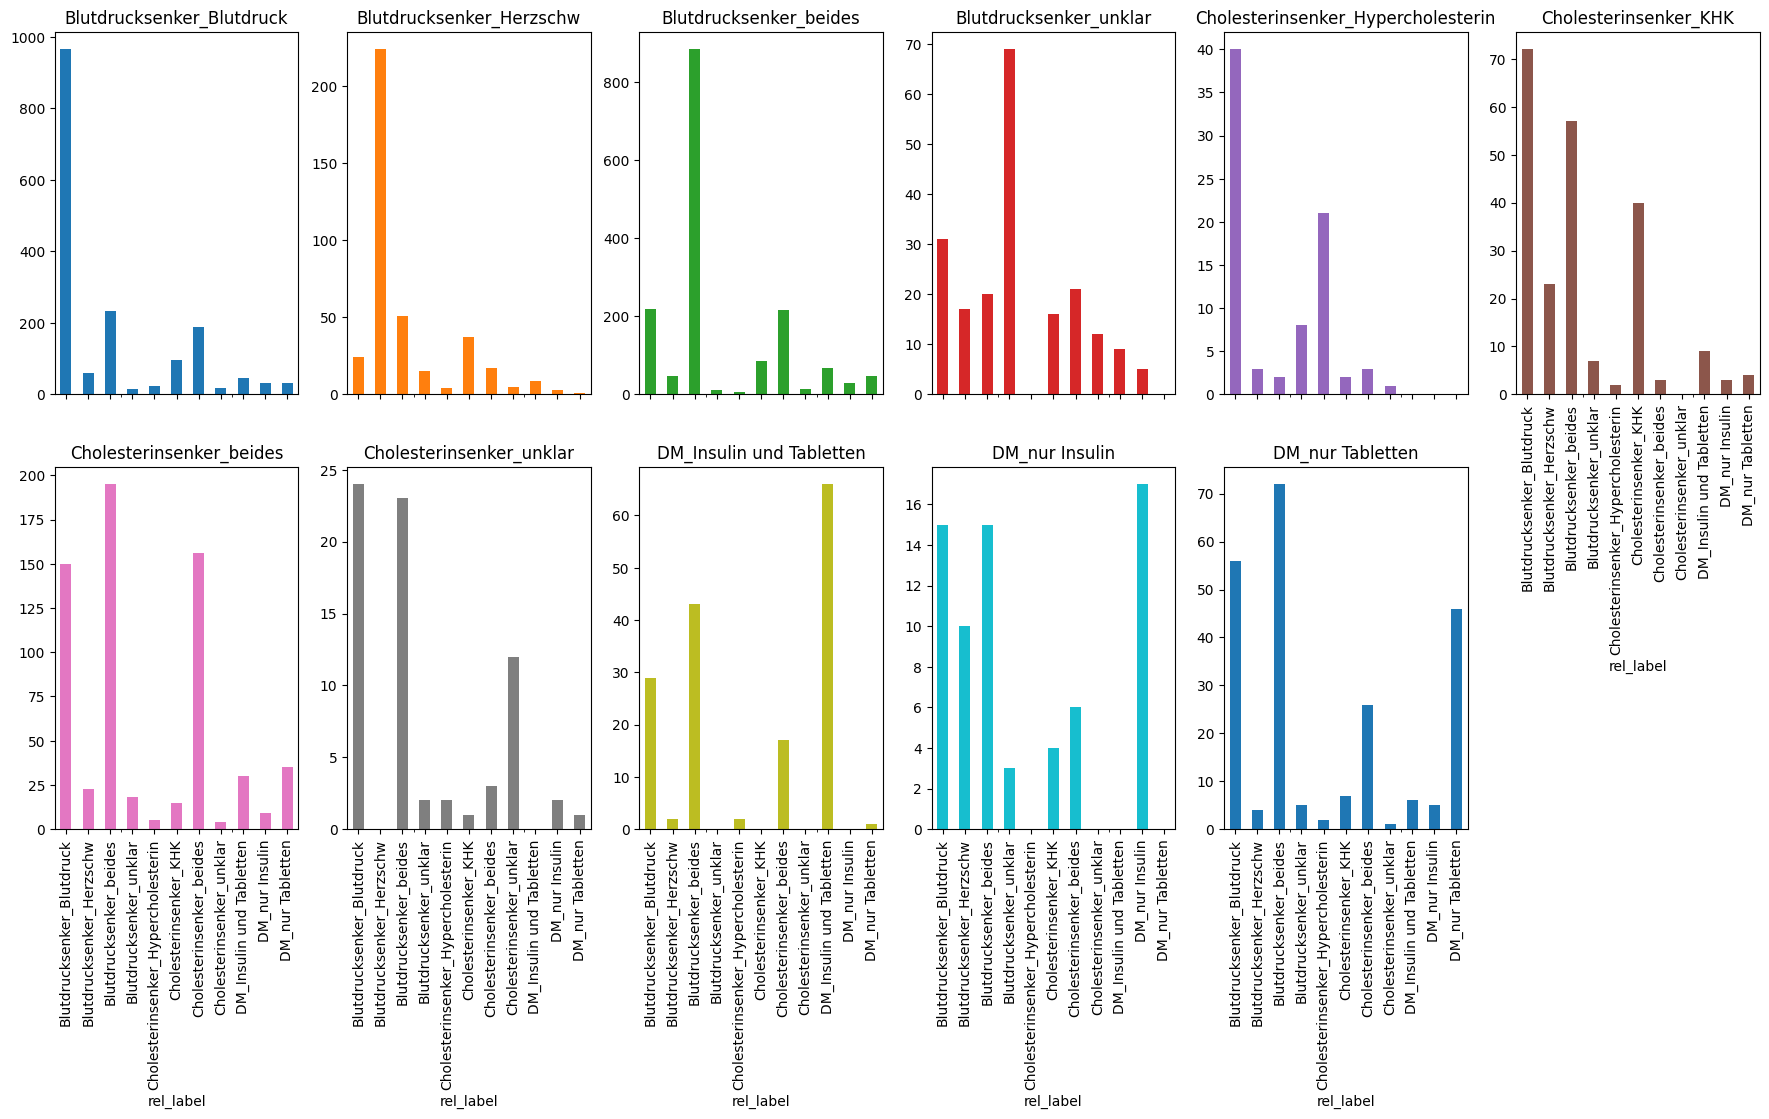

In [14]:
input_rel_label_vc = input_df.groupby("label")["rel_label"].value_counts()
input_rel_label_vc.unstack(level=0).plot(kind='bar', subplots=True, rot=90, figsize=(22, 16), sharex=True, layout=(3, 6), legend=False, xlabel=None)